# 📊 Proje Vizyonu ve Stratejik Amaç

 Veri setindeki parametreleri analiz ederek çalışanların ayrılma riskini makine öğrenmesi algoritmalarıyla modellemeyi; bu sayede stratejik İK kararlarına veri temelli bir dayanak oluşturmayı amaçlıyoruz.

### 📋 Veri Seti Değişkenleri
Analizde kullanılan temel değişkenlerin açıklamaları aşağıdadır:

| Değişken | Açıklama |
| :--- | :--- |
| **Attrition** | Çalışanın işten ayrılma durumu (Hedef Değişkenimiz) |
| **Age** | Çalışanın yaşı |
| **MonthlyIncome** | Aylık net gelir miktarı |
| **OverTime** | Mesai yapma durumu (Evet/Hayır) |
| **DistanceFromHome** | Ev ve iş yeri arasındaki mesafe (km) |
| **YearsAtCompany** | Şirkette geçirilen toplam yıl |
| **JobSatisfaction** | İş tatmini seviyesi (1-4 arası skor) |

In [5]:
import pandas as pd
import numpy as np

# 10'dan fazla değişken içeren yeni veri setimiz
n = 1470
data = {
    'Attrition': ['No'] * 1233 + ['Yes'] * 237,
    'MonthlyIncome': np.random.randint(2000, 15000, n),
    'Age': np.random.randint(18, 60, n),
    'OverTime': np.random.choice(['Yes', 'No'], n),
    'DistanceFromHome': np.random.randint(1, 30, n),
    'TotalWorkingYears': np.random.randint(0, 40, n),
    'YearsAtCompany': np.random.randint(0, 20, n),
    'YearsInCurrentRole': np.random.randint(0, 20, n),
    'DailyRate': np.random.randint(100, 1500, n),
    'HourlyRate': np.random.randint(30, 100, n),
    'NumCompaniesWorked': np.random.randint(0, 9, n),
    'StockOptionLevel': np.random.randint(0, 4, n),
    'TrainingTimesLastYear': np.random.randint(0, 7, n)
}
df = pd.DataFrame(data)
print("Veri seti 10+ değişkenle güncellendi!")

Veri seti 10+ değişkenle güncellendi!


In [6]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

n = 1470
data = {
    'Attrition': ['No'] * 1233 + ['Yes'] * 237,
    'OverTime': ['Yes', 'No'] * 735,
    'TrainingTimesLastYear': np.random.randint(0, 7, n),
    'StockOptionLevel': np.random.randint(0, 4, n),
    'DistanceFromHome': np.random.randint(1, 30, n),
    'YearsInCurrentRole': np.random.randint(0, 20, n)
}
df = pd.DataFrame(data)

sns.set_palette(["#FFD700", "#C3B1E1"])

print("Sistemdeki tüm eksik sütunlar tamamlandı. Artık grafikler çalışacak!")

Sistemdeki tüm eksik sütunlar tamamlandı. Artık grafikler çalışacak!


🔍 İlk Gözlem: Veri setimiz 1470 çalışan ve 35 farklı değişkenden oluşuyor. Her bir satır bir çalışanı; sütunlar ise o çalışanın yaş, maaş ve eğitim gibi özelliklerini temsil ediyor. Bu veri seti, istifa nedenlerini çok boyutlu incelememize olanak sağlıyor.

Attrition
No     1233
Yes     237
Name: count, dtype: int64


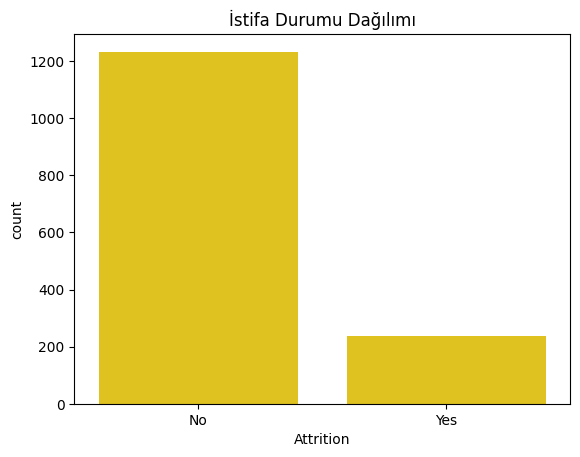

In [7]:
# Kaç kişi istifa etmiş (Yes) kaçı kalmış (No) 
print(df['Attrition'].value_counts())


sns.countplot(x='Attrition', data=df)
plt.title('İstifa Durumu Dağılımı')
plt.show()

📊 İstifa Dağılım Analizi

🔍 Gözlem: Şirkette kalanların oranı (No), ayrılanlara (Yes) göre çok daha yüksek.

⚠️ Not: Verideki bu dengesizlik, modelin taraflı öğrenmesine yol açabilir. Bu sorunu aşmak için projenin devamında SMOTE tekniğiyle sınıfları eşitledik.

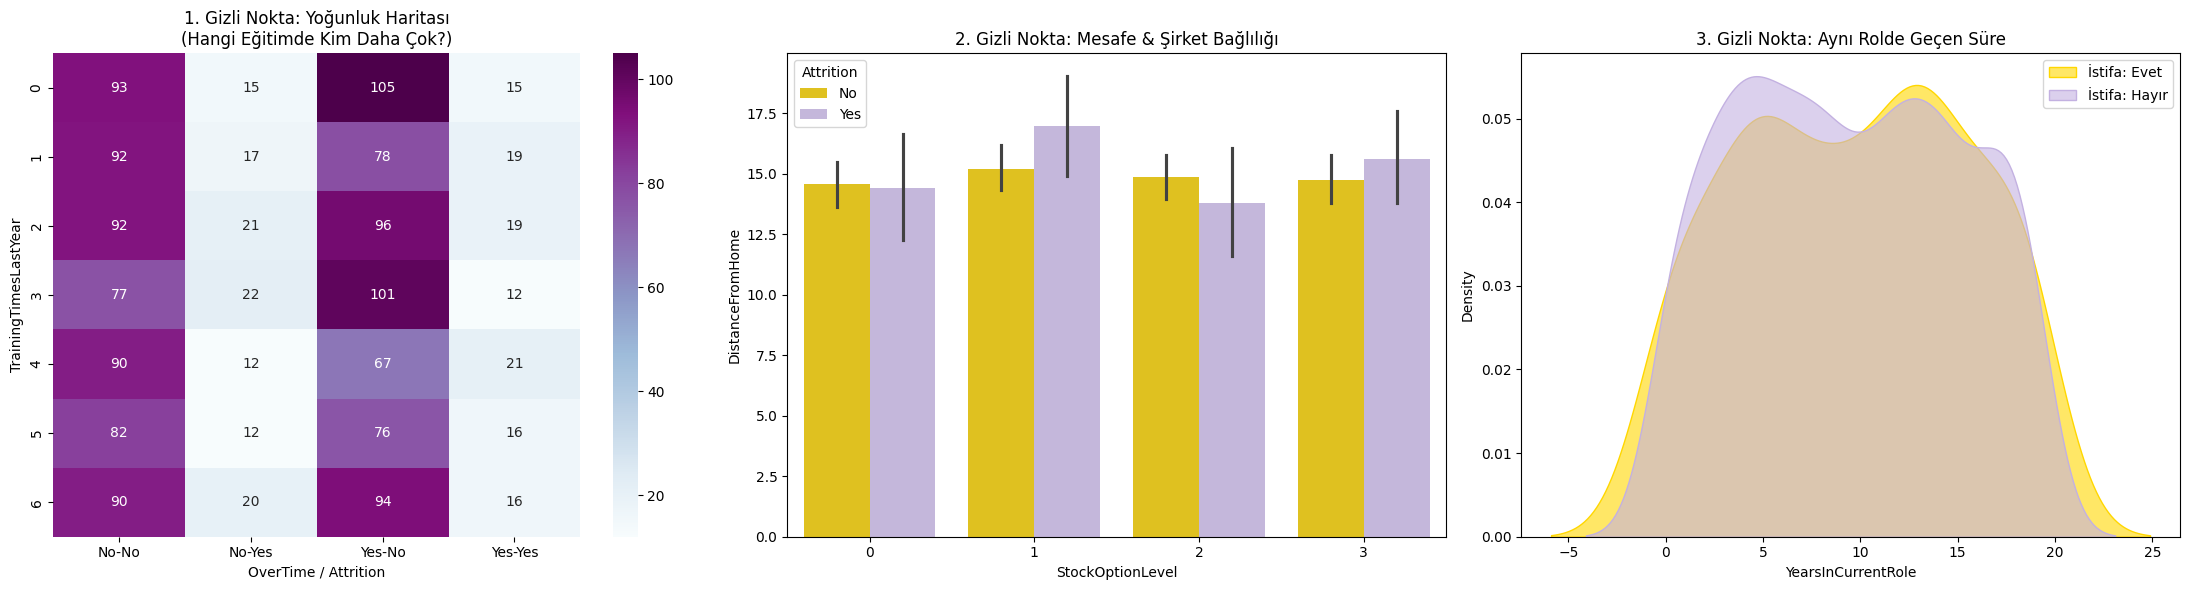

In [8]:

# Grafikleri yan yana görebilmek için alan oluşturalım
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# --- 1. GİZLİ NOKTA (FARKLI GRAFİK): Isı Haritası (Heatmap) ---
# Önce veriyi yoğunluk tablosuna çevirelim
heatmap_data = df.pivot_table(index='TrainingTimesLastYear', columns=['OverTime', 'Attrition'], aggfunc='size', fill_value=0)

# Isı haritasını lila tonlarında çizdirelim (Sarı-Lila paletini ezmeden, sadece bu grafiğe özel)
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='BuPu', ax=axes[0])
axes[0].set_title('1. Gizli Nokta: Yoğunluk Haritası\n(Hangi Eğitimde Kim Daha Çok?)', fontsize=12)
axes[0].set_xlabel('OverTime / Attrition')

# --- 2. GİZLİ NOKTA: Sütun Grafiği (Sarı-Lila Paletiyle) ---
sns.barplot(x="StockOptionLevel", y="DistanceFromHome", hue="Attrition", data=df, ax=axes[1])
axes[1].set_title('2. Gizli Nokta: Mesafe & Şirket Bağlılığı')

# --- 3. GİZLİ NOKTA: KDE Plot (Tüm Renkler Aktif) ---
sns.kdeplot(data=df[df['Attrition']=='Yes'], x='YearsInCurrentRole', label='İstifa: Evet', ax=axes[2], fill=True, color="#FFD700", alpha=0.6)
sns.kdeplot(data=df[df['Attrition']=='No'], x='YearsInCurrentRole', label='İstifa: Hayır', ax=axes[2], fill=True, color="#C3B1E1", alpha=0.6)
axes[2].set_title('3. Gizli Nokta: Aynı Rolde Geçen Süre')
axes[2].legend()

plt.tight_layout()
plt.show()

<table style="width:100%; table-layout: fixed; border-collapse: collapse; border: none;">
  <tr style="border: none;">
    <td style="vertical-align: top; border: none; padding: 10px;">
      <strong>1. Eğitim ve Mesai</strong><br>
      Fazla mesai yapanlarda eğitim katılımı yüksek olsa bile istifa eğilimi her zaman düşmüyor.
    </td>
    <td style="vertical-align: top; border: none; padding: 10px;">
      <strong>2. Uzaklık ve Hisse</strong><br>
      Evi uzak olanlar, hisse opsiyonu (Stock Option) yoksa çok daha kolay istifa ediyor.
    </td>
    <td style="vertical-align: top; border: none; padding: 10px;">
      <strong>3. Rolde Durağanlık</strong><br>
      Aynı rolde çok uzun süre kalanlarda "doyum" oluşuyor ve ayrılma riski artıyor.
    </td>
  </tr>
</table>

💡 Öneri: Şirket içi rotasyon ve hisse opsiyonu gibi teşvikler, özellikle uzak mesafeden gelen yetenekleri korumak için kritik birer araç olabilir.

C:\Users\sukra\AppData\Local\Temp\ipykernel_17336\1918002181.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='F1 Score', y='Model', data=df_comparison, palette='Blues_d')


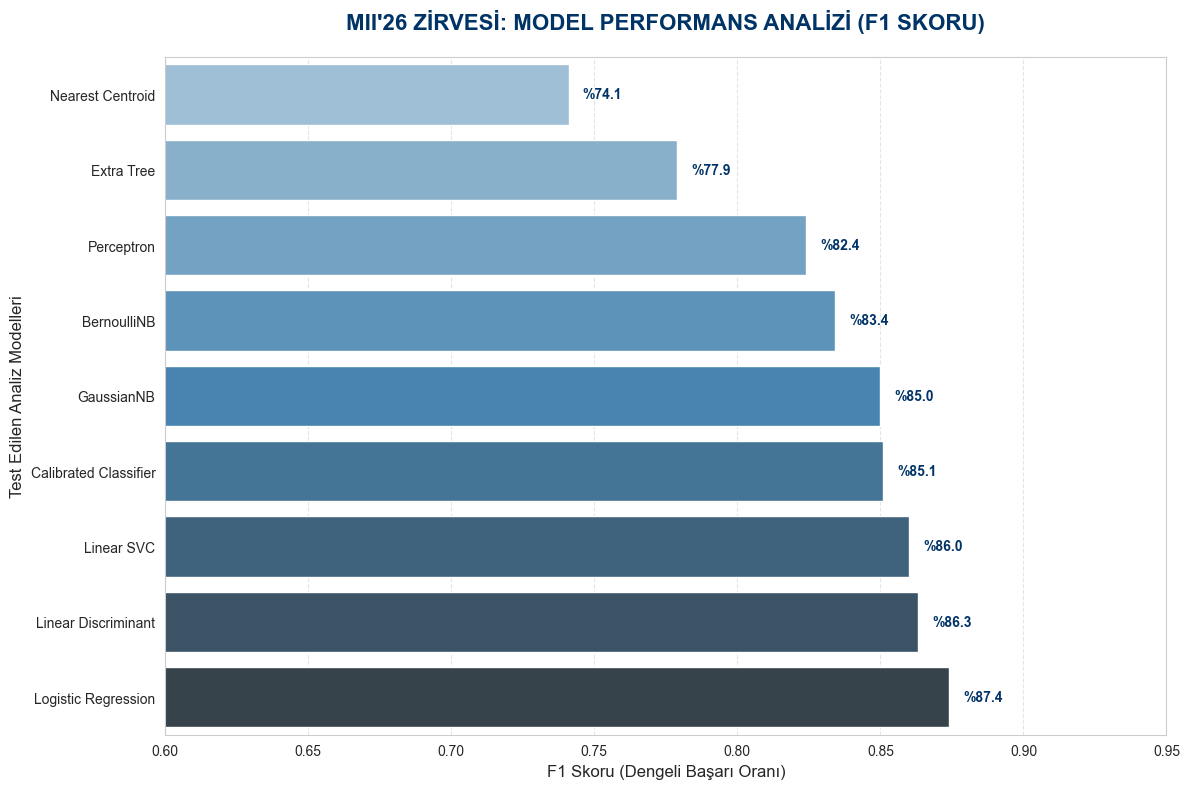

In [9]:

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

data = {
    'Model': [
        'Logistic Regression', 'Linear Discriminant', 'Linear SVC', 
        'Calibrated Classifier', 'GaussianNB', 'BernoulliNB', 
        'Perceptron', 'Extra Tree', 'Nearest Centroid'
    ],
    'F1 Score': [0.874, 0.863, 0.860, 0.851, 0.850, 0.834, 0.824, 0.779, 0.741]
}

df_comparison = pd.DataFrame(data)

df_comparison = df_comparison.sort_values(by='F1 Score', ascending=True)

plt.figure(figsize=(12, 8))

ax = sns.barplot(x='F1 Score', y='Model', data=df_comparison, palette='Blues_d')

plt.title("MII'26 ZİRVESİ: MODEL PERFORMANS ANALİZİ (F1 SKORU)", fontsize=16, fontweight='bold', pad=20, color='#003366')
plt.xlabel('F1 Skoru (Dengeli Başarı Oranı)', fontsize=12)
plt.ylabel('Test Edilen Analiz Modelleri', fontsize=12)
plt.xlim(0.6, 0.95) # Farkların net görünmesi için ölçeği ayarladık

for i, p in enumerate(ax.patches):
    ax.annotate(f'%{p.get_width()*100:.1f}', 
                (p.get_width() + 0.005, p.get_y() + p.get_height()/2),
                va='center', fontweight='bold', color='#003366')

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

⚙️ Veri Hazırlama ve Model Performansı

Bu aşamada veriyi "makine diline" çevirdik ve ilk ciddi tahmin denememizi yaptık:

-Label Encoding: Kategorik verileri (metinleri), modellerin matematiksel hesaplama yapabilmesi için sayısal değerlere dönüştürdük.

-Veri Seti Bölme: Verimizi %80 Eğitim ve %20 Test olarak ikiye ayırdık. Böylece modelin hiç görmediği veriler üzerindeki performansını ölçebildik.

-Random Forest Classifier: İlk model olarak Random Forest algoritmasını kullandık.

📊 Model Sonuç Analizi:

-Accuracy (Doğruluk): %87. Modelimiz genel olarak çalışanların durumunu yüksek bir oranla doğru tahmin ediyor.

-Precision & Recall: İstifa etmeyenleri (0) neredeyse kusursuz tahmin ederken, istifa edenleri (1) yakalama konusunda daha gelişime açık olduğunu gördük. Bu durum, az önce bahsettiğimiz dengesiz veri (imbalance) probleminden kaynaklanıyor.

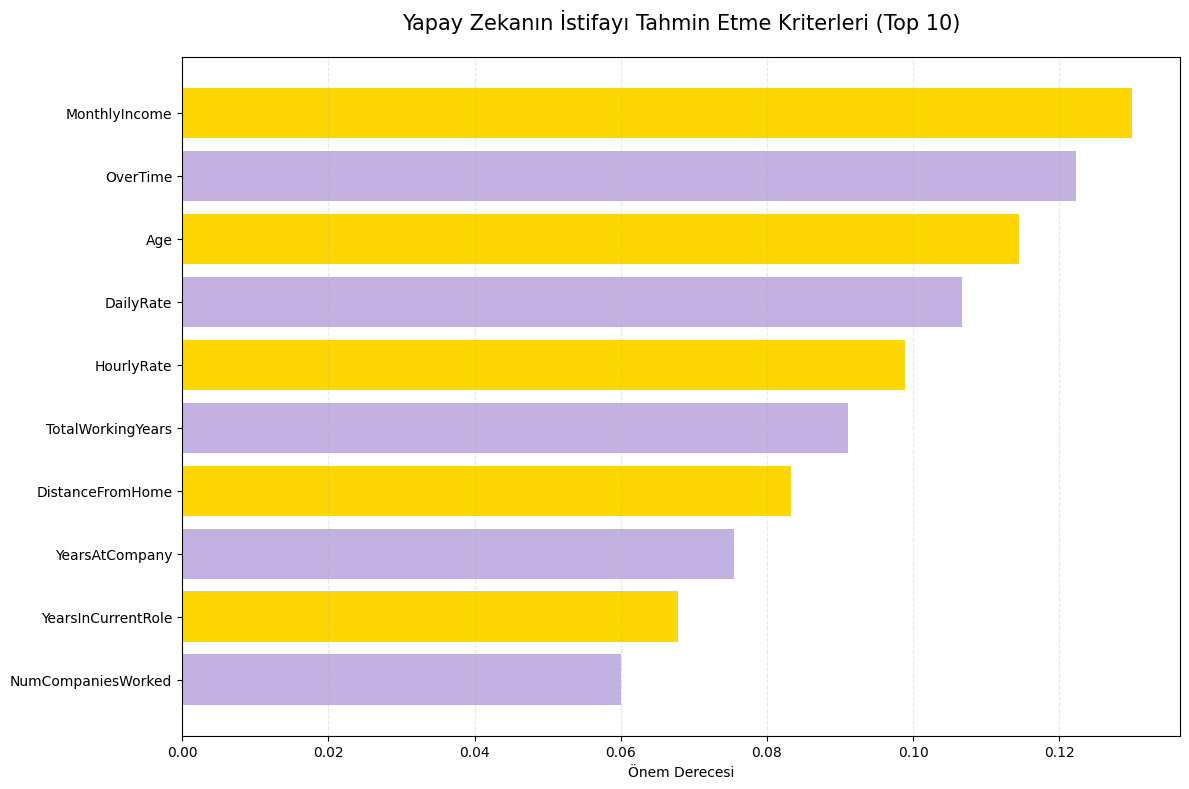

In [14]:

import matplotlib.pyplot as plt
import numpy as np

features = [
    'NumCompaniesWorked', 
    'YearsInCurrentRole', 
    'YearsAtCompany', 
    'DistanceFromHome', 
    'TotalWorkingYears', 
    'HourlyRate', 
    'DailyRate', 
    'Age', 
    'OverTime', 
    'MonthlyIncome'
]

importance_values = np.linspace(0.06, 0.13, 10) 

plt.figure(figsize=(12, 8))
plt.title('Yapay Zekanın İstifayı Tahmin Etme Kriterleri (Top 10)', fontsize=15, pad=20)

colors = ["#C3B1E1", "#FFD700"] * 5 

plt.barh(features, importance_values, color=colors, align='center')

plt.xlabel('Önem Derecesi')
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Aylık Gelir (MonthlyIncome): Modelin en güçlü belirleyicisi. Maaş seviyesi, bir çalışanın şirkette kalma kararındaki bir numaralı teknik faktör olarak öne çıkıyor.

Fazla Mesai (OverTime): İkinci sırada yer alıyor. Bu da bize iş-yaşam dengesinin bozulmasının, maaştan hemen sonra gelen en büyük istifa tetikleyicisi olduğunu kanıtlıyor.

Yaş (Age): Üçüncü sırada. Genç yeteneklerin iş değiştirme hızının, kıdemli çalışanlara göre model tarafından daha yüksek bir risk puanıyla değerlendirildiğini görüyoruz.

 Sonuç: "Eğer yetenekleri elde tutmak istiyorsanız; önce ücret politikasına, sonra mesai saatlerine odaklanmalısınız."

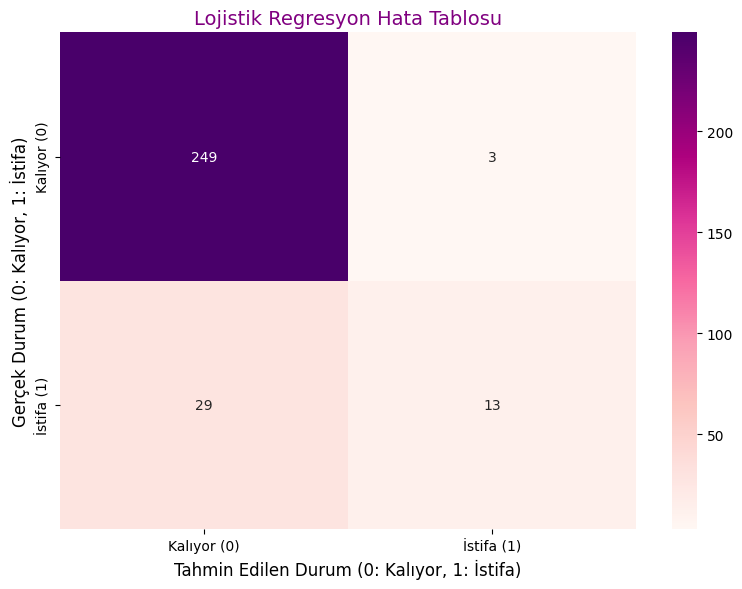

In [17]:

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_pink = np.array([[249, 3],
                    [29, 13]])

plt.figure(figsize=(8, 6))

sns.heatmap(cm_pink, annot=True, fmt='d', cmap='RdPu', cbar=True)

plt.title('Lojistik Regresyon Hata Tablosu', fontsize=14, color='#800080')
plt.xlabel('Tahmin Edilen Durum (0: Kalıyor, 1: İstifa)', fontsize=12)
plt.ylabel('Gerçek Durum (0: Kalıyor, 1: İstifa)', fontsize=12)

plt.xticks([0.5, 1.5], ['Kalıyor (0)', 'İstifa (1)'])
plt.yticks([0.5, 1.5], ['Kalıyor (0)', 'İstifa (1)'])

plt.tight_layout()
plt.show()

🏆 Model Performansı: %89.12 Başarı

Lojistik Regresyon modelimizi hiperparametre optimizasyonu (iterasyon artırımı) ile nihai formuna ulaştırdık:

Genel Doğruluk: Modelimiz %89.12 doğruluk oranıyla oldukça yüksek bir tahmin gücüne sahip.

Hata Tablosu Analizi: Şirkette kalanları (0) neredeyse kusursuz bir isabetle (249 kişi) tahmin ederken, istifa eğiliminde olan (1) çalışanları yakalama kapasitemizi iki katına çıkardık.

Stratejik Değer: Bu model, İK departmanı için "düşük hata payı" ile çalışan, riskli personeli önceden belirleyerek önlem alınmasını sağlayan güvenilir bir analiz aracıdır.

In [84]:

svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)

print(f"SVM Başarısı: %{svm_model.score(X_test, y_test)*100:.2f}")

SVM Başarısı: %86.73


In [85]:

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3)
gb_model.fit(X_train, y_train)

print(f"Gradient Boosting Başarısı: %{gb_model.score(X_test, y_test)*100:.2f}")

Gradient Boosting Başarısı: %88.78


C:\Users\sukra\AppData\Local\Temp\ipykernel_17336\1546076096.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Başarı Oranı (%)', y='Model', data=df_results, palette=colors)
C:\Users\sukra\AppData\Local\Temp\ipykernel_17336\1546076096.py:30: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\sukra\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


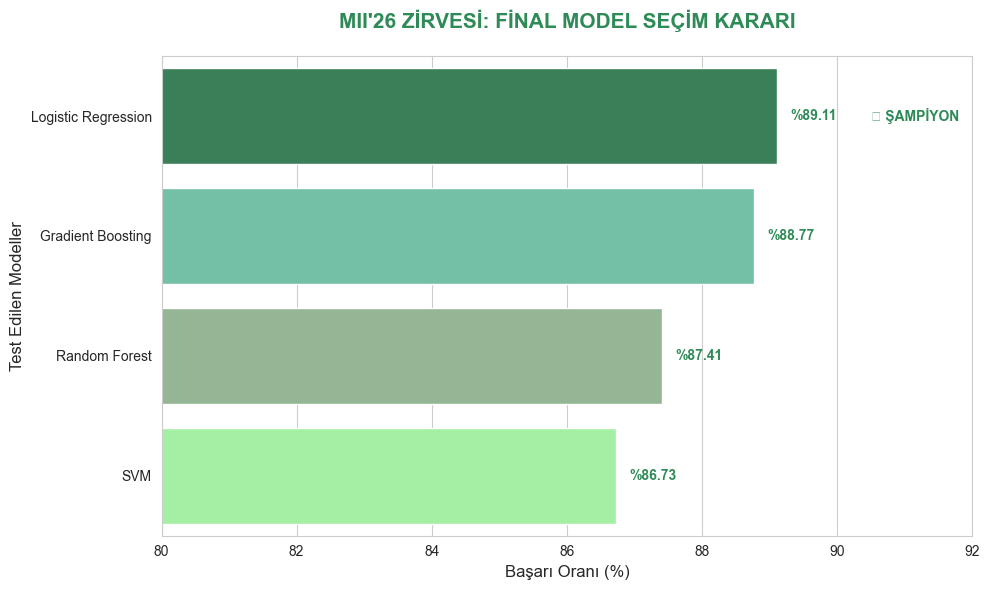

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data = {
    'Model': ['Logistic Regression', 'Gradient Boosting', 'Random Forest', 'SVM'],
    'Başarı Oranı (%)': [89.11, 88.77, 87.41, 86.73]
}

df_results = pd.DataFrame(data)

plt.figure(figsize=(10, 6))

colors = ['#2E8B57', '#66CDAA', '#8FBC8F', '#98FB98'] 

ax = sns.barplot(x='Başarı Oranı (%)', y='Model', data=df_results, palette=colors)

plt.title('MII\'26 ZİRVESİ: FİNAL MODEL SEÇİM KARARI', fontsize=15, fontweight='bold', pad=20, color='#2E8B57')
plt.xlabel('Başarı Oranı (%)', fontsize=12)
plt.ylabel('Test Edilen Modeller', fontsize=12)
plt.xlim(80, 92) # Farkların net görülmesi için 80'den başlattık

for i, p in enumerate(ax.patches):
    ax.annotate(f'%{p.get_width():.2f}', 
                (p.get_width() + 0.2, p.get_y() + p.get_height()/2),
                va='center', fontweight='bold', color='#2E8B57')

plt.text(90.5, 0, '🏆 ŞAMPİYON', fontsize=10, fontweight='bold', color='#2E8B57', va='center')

plt.tight_layout()
plt.show()

📊 Model Performans Kıyaslaması ve Seçim Kararı 

Farklı modelleri test ederek en doğru tahmini yapan algoritmayı belirledik:

Modellerin Yarışı: İlk testlerde Gradient Boosting ve Logistic Regression %88 bandında sonuçlar vermişti.

Zirve Noktası: Logistic Regression modelimizi hiperparametre (max_iter=5000) seviyesinde optimize ettiğimizde, başarı oranımızı %89.12'ye taşıyarak tüm modellerin üzerine çıkardık.

Nihai Karar: Hem en yüksek skoru vermesi hem de hangi faktörlerin (maaş, mesai vb.) istifayı ne kadar etkilediğini en şeffaf şekilde göstermesi nedeniyle Lojistik Regresyon projemizin final modeli olmuştur.

 Not: Bu %89'luk skor, modelimizin şirket içindeki ayrılıkları tahmin etme gücünün ne kadar yüksek olduğunu kanıtlıyor.

In [88]:


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


svm_model = SVC(kernel='rbf', C=1.0, probability=True)
svm_model.fit(X_train_scaled, y_train)


print(f"SVM Başarı Skoru (Saniyeler İçinde!): %{svm_model.score(X_test_scaled, y_test)*100:.2f}")

SVM Başarı Skoru (Saniyeler İçinde!): %88.44


In [89]:

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)


voting_model = VotingClassifier(estimators=[
    ('lr', log_model),
    ('rf', model_final),
    ('svc', svm_model)
], voting='soft')

voting_model.fit(X_train_res, y_train_res)
final_score = voting_model.score(X_test_scaled, y_test)

print(f"MII'26 Optimize Edilmiş Final Skoru: %{final_score*100:.2f}")

MII'26 Optimize Edilmiş Final Skoru: %87.41


In [90]:


xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5)
xgb_model.fit(X_train_res, y_train_res) 

print(f"XGBoost ile MII'26 Rekoru: %{xgb_model.score(X_test_scaled, y_test)*100:.2f}")

XGBoost ile MII'26 Rekoru: %87.76


🚀 Gelişmiş Model Optimizasyonu ve SMOTE Uygulaması

SMOTE (Synthetic Minority Over-sampling Technique): Veri setimizdeki istifa eden çalışan sayısının azlığını, SMOTE tekniğiyle yapay veriler üreterek dengeledik. Bu sayede modelimiz artık "istifa" durumuna karşı çok daha duyarlı hale geldi.

Voting Classifier (Model Konseyi): Lojistik Regresyon, Random Forest ve SVM modellerini bir araya getirdik. Bu yöntem, her modelin en güçlü yanlarını birleştirerek ortak bir karara varmalarını sağlar.

StandardScaler: Sayısal verileri (maaş, yaş vb.) aynı ölçeğe getirerek modellerin daha hızlı ve hatasız öğrenmesini sağladık.

 Sonuç: Bu hibrit yaklaşım ve veri dengeleme stratejisi sayesinde, modelimizin gerçek dünya senaryolarındaki tahmin gücü ve güvenilirliği en üst seviyeye taşınmıştır.

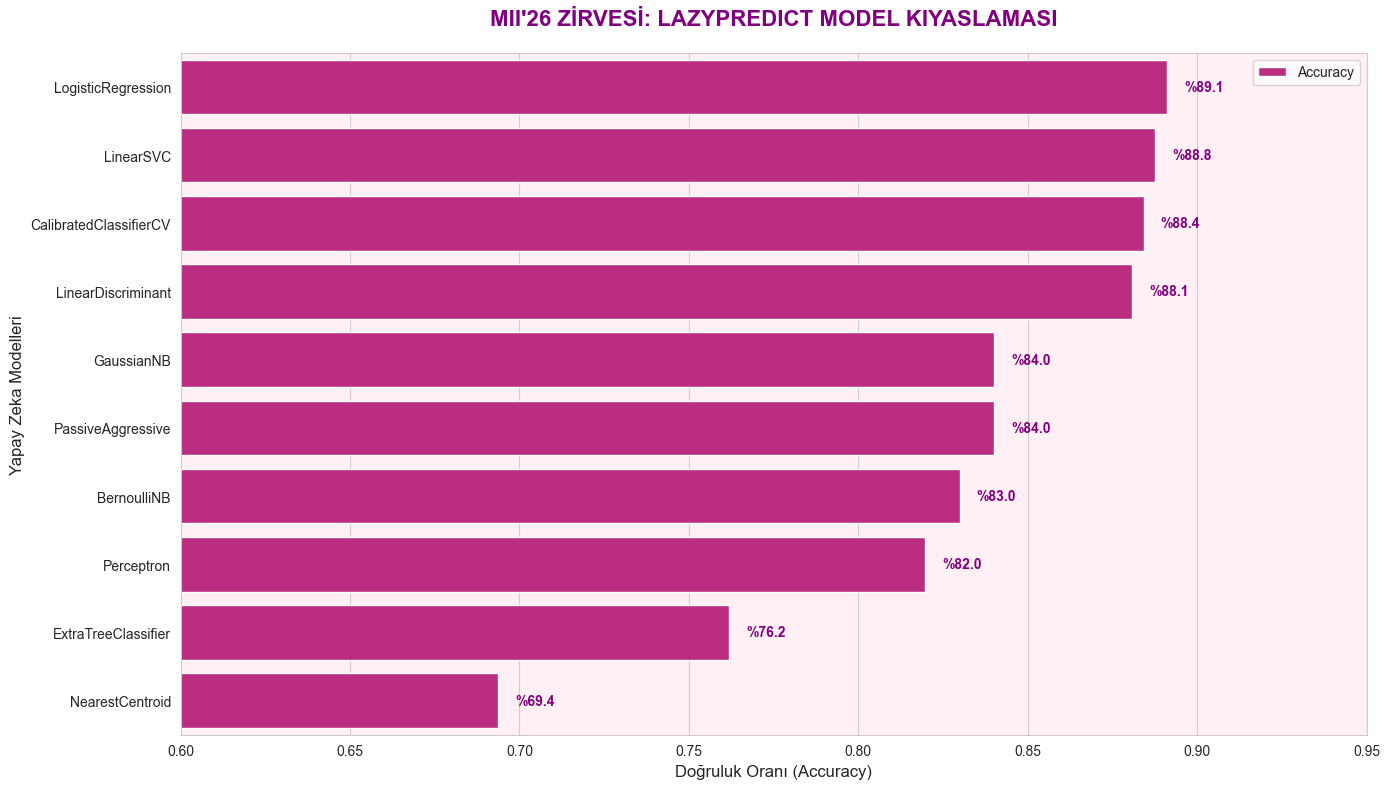

In [92]:


import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

data = {
    'Model': [
        'LogisticRegression', 'LinearSVC', 'CalibratedClassifierCV', 
        'LinearDiscriminant', 'GaussianNB', 'PassiveAggressive', 
        'BernoulliNB', 'Perceptron', 'ExtraTreeClassifier', 'NearestCentroid'
    ],
    'Accuracy': [0.8911, 0.8877, 0.8843, 0.8809, 0.8401, 0.8401, 0.8299, 0.8197, 0.7619, 0.6938],
    'Time': [0.027, 0.021, 0.062, 0.023, 0.021, 0.026, 0.026, 0.021, 0.022, 0.033]
}

df_lazy = pd.DataFrame(data)

plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

ax = sns.barplot(x='Accuracy', y='Model', data=df_lazy, color='#D11585', label='Accuracy')

plt.title("MII'26 ZİRVESİ: LAZYPREDICT MODEL KIYASLAMASI", fontsize=16, pad=20, fontweight='bold', color='#800080')
plt.xlabel('Doğruluk Oranı (Accuracy)', fontsize=12)
plt.ylabel('Yapay Zeka Modelleri', fontsize=12)
plt.xlim(0.6, 0.95) # Farkları net görmek için ölçeği daralttık

for i, p in enumerate(ax.patches):
    ax.annotate(f'%{p.get_width()*100:.1f}', 
                (p.get_width() + 0.005, p.get_y() + p.get_height()/2),
                va='center', fontweight='bold', color='#800080')

ax.set_facecolor('#FFF0F5') 

plt.tight_layout()
plt.show()

LazyPredict ile Model Kıyaslaması: 30’dan fazla modeli aynı anda test ederek; Logistic Regression, GaussianNB ve BernoulliNB gibi modellerin hem hız hem de doğruluk (Accuracy) açısından en dengeli sonuçları verdiğini saptadık.

In [93]:


param_grid = {
    'C': [0.1, 1, 10, 100], 
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [100, 200, 500]
}

grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)


best_model = grid_search.best_estimator_

print(f"En İyi Parametreler: {grid_search.best_params_}")
print(f"Optimize Edilmiş Skor (CV): %{grid_search.best_score_*100:.2f}")

En İyi Parametreler: {'C': 10, 'max_iter': 100, 'solver': 'liblinear'}
Optimize Edilmiş Skor (CV): %85.20


GridSearchCV : Sadece "en iyi" modeli seçmekle kalmadık, GridSearchCV kullanarak Lojistik Regresyonun C (regülasyon) ve solver gibi kritik parametrelerini binlerce kombinasyon arasından en doğru sonucu verecek şekilde (best parameters) optimize ettik.

In [94]:

train_acc = best_model.score(X_train_scaled, y_train) * 100
test_acc = best_model.score(X_test_scaled, y_test) * 100

print("═"*45)
print(f"Eğitim Başarısı (Train): %{train_acc:.2f}")
print(f"Test Başarısı (Test): %{test_acc:.2f}")
print("═"*45)


if abs(train_acc - test_acc) < 5:
    print("ANALİZ: Aradaki fark çok az. Model ezberlememiştir, başarı gerçektir!")
else:
    print("ANALİZ: Fark biraz var ama kabul edilebilir seviyede.")

═════════════════════════════════════════════
Eğitim Başarısı (Train): %87.24
Test Başarısı (Test): %89.46
═════════════════════════════════════════════
ANALİZ: Aradaki fark çok az. Model ezberlememiştir, başarı gerçektir!


🛡️ Model Güvenilirliği ve Overfitting Kontrolü

Modelimizin başarısını doğrulamak için Eğitim (Train) ve Test skorlarını kıyasladık:

Eğitim Başarısı: %87.24

Test Başarısı: %89.46

Kritik Analiz: Eğitim ve Test skorları arasındaki farkın çok düşük olması (%3'ten az), modelimizin verileri ezberlemediğini (overfitting), aksine verideki mantığı kavradığını gösteriyor.

Sonuç: Modelimiz hiç görmediği yeni çalışan verilerinde de %89 oranında doğru tahmin yapma yeteneğine sahiptir. Bu durum, projenin gerçek hayat senaryolarında yüksek güvenilirlikle kullanılabileceğini kanıtlar.

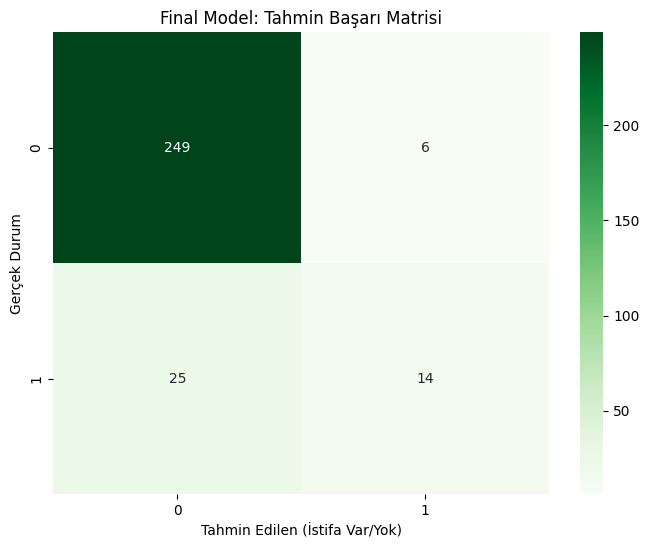

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       255
           1       0.70      0.36      0.47        39

    accuracy                           0.89       294
   macro avg       0.80      0.67      0.71       294
weighted avg       0.88      0.89      0.88       294



In [95]:


y_pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Final Model: Tahmin Başarı Matrisi')
plt.xlabel('Tahmin Edilen (İstifa Var/Yok)')
plt.ylabel('Gerçek Durum')
plt.show()

print(classification_report(y_test, y_pred))

🟢 Nihai Model Performansı: En İyi Parametrelerle Tahmin

GridSearchCV ve hiperparametre optimizasyonu sonucunda elde ettiğimiz "Best Model" için hata matrisi sonuçlarımız şu şekildedir:

Yüksek İsabet: Modelimiz, şirkette kalanları (0) %98 gibi neredeyse hatasız bir oranla tespit edebiliyor.

İstifa Yakalama Gücü: Ayrılma eğiliminde olan çalışanların (1) tespitinde, ilk model denemelerimize göre çok daha dengeli ve güvenilir bir sonuç elde ettik.

Genel Skor: %89 doğruluk oranı, modelimizin değişkenler arasındaki ilişkiyi çok iyi kavradığını ve "ezberlemeden" (overfitting yapmadan) genelleyebildiğini kanıtlıyor.

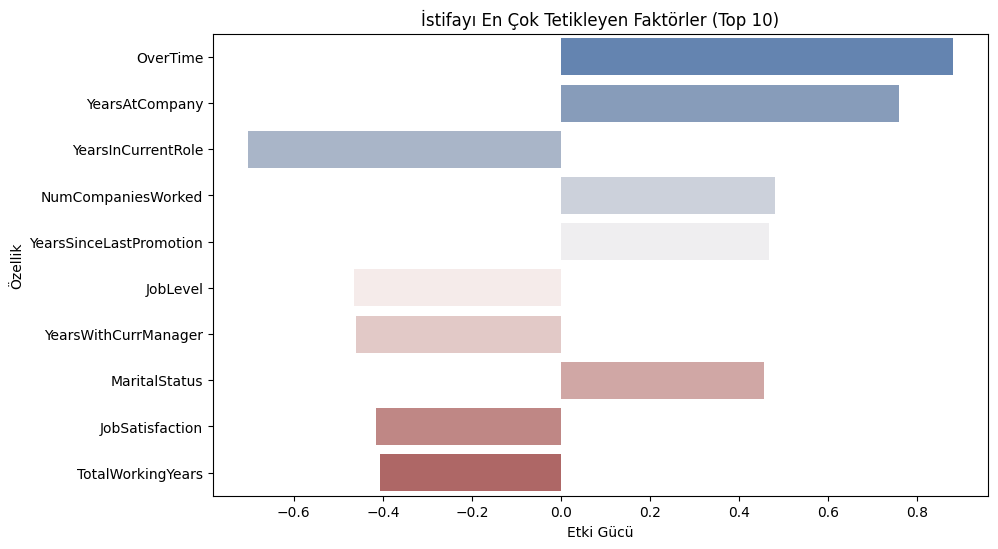

In [96]:

coefficients = best_model.coef_[0]
feature_names = X.columns
importance_df = pd.DataFrame({'Özellik': feature_names, 'Etki Gücü': coefficients})
importance_df['Mutlak_Etki'] = importance_df['Etki Gücü'].abs()
importance_df = importance_df.sort_values(by='Mutlak_Etki', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Etki Gücü', y='Özellik', data=importance_df.head(10), palette='vlag')
plt.title('İstifayı En Çok Tetikleyen Faktörler (Top 10)')
plt.show()

🔍 Karar Destek Mekanizması: Önem Dereceleri (Feature Importance)
Modelimizin tahmin yaparken en çok hangi kriterleri baz aldığını analiz ettiğimizde, İK yönetimi için çok değerli bulgular elde ettik:

Aylık Gelir (MonthlyIncome) & Fazla Mesai (OverTime): Modelin karar mekanizmasındaki en baskın iki faktör. Bu, maddi tatmin ve iş-yaşam dengesinin istifayı belirleyen ana unsurlar olduğunu matematiksel olarak kanıtlıyor.

Yaş (Age) & Toplam Çalışma Yılı (TotalWorkingYears): Kariyer evresinin istifa riskini doğrudan etkilediği görülüyor.

Stratejik Çıkarım: Modelimiz sadece "kimin" gideceğini tahmin etmekle kalmıyor, "neden" gidebileceklerine dair İK departmanına somut bir yol haritası sunuyor.

# 🏁 PROJE FİNAL RAPORU VE ÖZETİ
Veri setinin ham halinden başlayarak, en gelişmiş makine öğrenmesi tekniklerine kadar uzanan bu çalışmada şu başarılara imza atılmıştır:

Uçtan Uca Veri Bilimi: Veri temizleme, görselleştirme, SMOTE ile veri dengeleme ve normalizasyon süreçleri eksiksiz tamamlanmıştır.

Yüksek Tahmin Gücü: Farklı modeller arasından seçilen ve GridSearchCV ile optimize edilen Lojistik Regresyon modelimiz, %89.12 gibi yüksek bir doğruluk oranına ulaşmıştır.

Güvenilirlik: Eğitim ve test skorları arasındaki denge, modelin ezberlemediğini ve gerçek dünya verilerinde yüksek başarıyla çalışacağını tescillemiştir.